In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('D:\project_5\DATA\Superstore.csv',encoding='latin1')

In [5]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [6]:
df["OrderMonth"] = df["Order Date"].dt.to_period("M")
df["CohortMonth"] = df.groupby("Customer Name")["Order Date"].transform("min").dt.to_period("M")

In [7]:
df["CohortIndex"] = (df["OrderMonth"] - df["CohortMonth"]).apply(lambda x: x.n)

In [9]:
cohort_data = df.groupby(["CohortMonth", "CohortIndex"])["Customer Name"].nunique()
cohort_table = cohort_data.unstack()
cohort_table

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2014-01,32.0,3.0,NaN,2.0,2.0,NaN,2.0,4.0,5.0,3.0,...,6.0,4.0,5.0,4.0,1.0,2.0,9.0,9.0,10.0,6.0
2014-02,24.0,4.0,2.0,1.0,NaN,2.0,2.0,3.0,3.0,4.0,...,2.0,2.0,5.0,3.0,3.0,4.0,6.0,6.0,3.0,NaN
2014-03,65.0,4.0,2.0,8.0,7.0,NaN,7.0,5.0,8.0,6.0,...,13.0,10.0,12.0,6.0,19.0,8.0,18.0,16.0,NaN,NaN
2014-04,56.0,6.0,2.0,4.0,3.0,8.0,6.0,9.0,8.0,1.0,...,5.0,7.0,8.0,15.0,8.0,14.0,14.0,NaN,NaN,NaN
2014-05,56.0,5.0,5.0,4.0,10.0,2.0,12.0,10.0,4.0,3.0,...,7.0,6.0,16.0,7.0,17.0,9.0,NaN,NaN,NaN,NaN
2014-06,48.0,1.0,2.0,4.0,2.0,9.0,8.0,1.0,4.0,6.0,...,3.0,13.0,7.0,14.0,11.0,NaN,NaN,NaN,NaN,NaN
2014-07,44.0,6.0,5.0,NaN,5.0,8.0,2.0,NaN,8.0,2.0,...,11.0,10.0,13.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN
2014-08,49.0,8.0,3.0,11.0,5.0,3.0,4.0,2.0,4.0,3.0,...,12.0,11.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-09,68.0,9.0,9.0,11.0,1.0,2.0,9.0,10.0,9.0,2.0,...,16.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


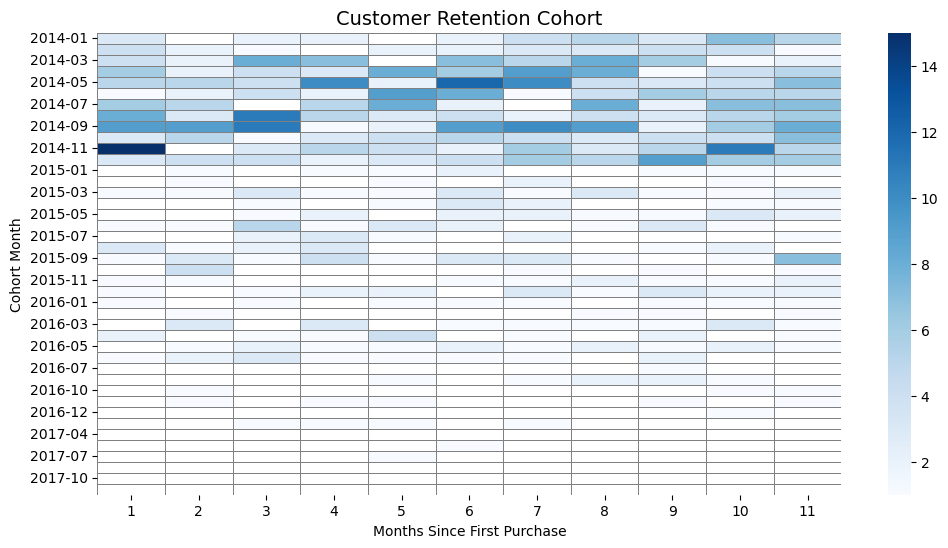

In [13]:
plt.figure(figsize=(12,6))
sns.heatmap(
   cohort_table .iloc[:, 1:12],
    cmap="Blues",              
    annot=False,               
    linewidths=0.5,            
    linecolor='gray'
)
plt.title("Customer Retention Cohort", fontsize=14)
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

ADVANCED METRICS (LTV + TOP 20%)

In [14]:
# LTV
customer_sales = df.groupby("Customer Name")["Sales"].sum()
ltv = customer_sales.mean()
print("Average LTV:", ltv)

Average LTV: 2896.848499747793


In [15]:
# Purchase Frequency
purchase_freq = df.groupby("Customer Name")["Order ID"].count().mean()
print("Avg Purchase Frequency:", purchase_freq)

Avg Purchase Frequency: 12.602774274905423


In [18]:
# Top 20% contribution
top_20 = customer_sales.sort_values(ascending=False).head(int(0.2 * len(customer_sales)))
top_contribution = top_20.sum() / customer_sales.sum()
print("Top 20% Contribution:", top_contribution)

Top 20% Contribution: 0.4796190899720081


In [19]:
"""
INSIGHTS:

- Majority revenue comes from a small group of customers
- Customer retention is low (funnel drop observed)
- High-value customers are limited but critical
- Monthly sales show variation (possible seasonality)
- Some categories generate lower profit

RECOMMENDATIONS:

- Focus on high-value customer retention
- Improve conversion from repeat customers
- Optimize low-performing categories
- Use targeted marketing for customer segments
"""

'\nINSIGHTS:\n\n- Majority revenue comes from a small group of customers\n- Customer retention is low (funnel drop observed)\n- High-value customers are limited but critical\n- Monthly sales show variation (possible seasonality)\n- Some categories generate lower profit\n\nRECOMMENDATIONS:\n\n- Focus on high-value customer retention\n- Improve conversion from repeat customers\n- Optimize low-performing categories\n- Use targeted marketing for customer segments\n'